# **Final Task: FairClean pipeline on International Graduates Dataset on the Logistic Regression model.**

#1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#2. Load Dataset
Here, thesame dataset as used in the FairCleanGradModel.ipynb was used here as well.

In [2]:
df = pd.read_csv("/content/drive/MyDrive/dataset.csv").reset_index(drop=True)

#3. Data Cleaning: Standardize Target, Sensitive Attribute, and Key Features

In [3]:
# 1. CLEAN TARGET COLUMN
# ============================================================

df["Employment_Status"] = df["Employment_Status"].astype(str).str.strip()

target_map = {
    "Employed": 1,
    "Unemployed": 0,
    "Yes": 1,
    "No": 0,
    "employed": 1,
    "unemployed": 0
}

df["employment"] = df["Employment_Status"].map(target_map)
df = df.dropna(subset=["employment"]).reset_index(drop=True)

# ============================================================
# 2. CLEAN SENSITIVE ATTRIBUTE
# ============================================================

df["Gender"] = df["Gender"].astype(str).str.strip()

gender_map = {"Male": 1, "Female": 0, "M": 1, "F": 0}
df["gender_bin"] = df["Gender"].map(gender_map)
df = df.dropna(subset=["gender_bin"]).reset_index(drop=True)

# ============================================================
# 3. CLEAN INTERNSHIP EXPERIENCE
# ============================================================

df["Internship_Experience"] = df["Internship_Experience"].astype(str).str.strip()

intern_map = {"Yes": 1, "No": 0, "Y": 1, "N": 0}
df["internship_bin"] = df["Internship_Experience"].map(intern_map)
df = df.dropna(subset=["internship_bin"]).reset_index(drop=True)

# ============================================================
# 4. DROP ORIGINAL STRING COLUMNS
# ============================================================

df = df.drop(columns=["Employment_Status", "Gender", "Internship_Experience"])

#4. One- Hot Encoding

In [4]:
categorical_cols = [
    "Country_of_Origin",
    "Education_Level",
    "Field_of_Study",
    "Language_Proficiency",
    "Visa_Type",
    "University_Ranking",
    "Region_of_Study",
    "Job_Sector"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df = df.reset_index(drop=True)

#5. Train Logistic Regression Model

In [5]:
def train_model(df, sample_weight=None):
    X = df.drop(columns=["employment"])
    y = df["employment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=500, class_weight="balanced")

    if sample_weight is not None:
        model.fit(X_train_scaled, y_train, sample_weight=sample_weight.loc[y_train.index])
    else:
        model.fit(X_train_scaled, y_train)

    return model, X_train, X_test, y_train, y_test, scaler

#6. Fairness Metrics

In [6]:
def compute_fairness(df, model, scaler):
    X = df.drop(columns=["employment"])
    X_scaled = scaler.transform(X)
    preds = model.predict(X_scaled)

    tmp = df.copy()
    tmp["pred"] = preds

    rates = tmp.groupby("gender_bin")["pred"].mean().to_dict()
    g0, g1 = 0, 1
    gap = rates[g1] - rates[g0]
    ratio = rates[g0] / rates[g1] if rates[g1] > 0 else np.nan

    return {"rates": rates, "gap": gap, "ratio": ratio}

#7. Vectorised Counterfactuals

In [7]:
def attribute_cf_fast(df, model, scaler, X_cols):
    X = df[X_cols].copy()
    factual = model.predict(scaler.transform(X))

    X_cf = X.copy()
    X_cf["gender_bin"] = 1 - X_cf["gender_bin"]

    cf = model.predict(scaler.transform(X_cf))
    return np.where(factual != cf)[0].tolist()

def causal_cf_fast(df, model, scaler, X_cols):
    return attribute_cf_fast(df, model, scaler, X_cols)

#8. Structural Uplift Rules

In [8]:
def structural_cf_fast(df, model, scaler, X_cols):
    X = df[X_cols].copy()
    factual = model.predict(scaler.transform(X))

    X_cf = X.copy()

    # 1. EDUCATION UPLIFT
    edu_cols = [c for c in X_cf.columns if c.startswith("Education_Level_")]
    if edu_cols:
        X_cf[edu_cols] = 0
        X_cf[edu_cols[-1]] = 1

    # 2. UNIVERSITY RANKING UPLIFT
    rank_cols = [c for c in X_cf.columns if c.startswith("University_Ranking_")]
    if rank_cols:
        X_cf[rank_cols] = 0
        X_cf[rank_cols[0]] = 1

    # 3. LANGUAGE PROFICIENCY UPLIFT
    lang_cols = [c for c in X_cf.columns if c.startswith("Language_Proficiency_")]
    if lang_cols:
        X_cf[lang_cols] = 0
        X_cf[lang_cols[-1]] = 1

    # 4. INTERNSHIP UPLIFT
    if "internship_bin" in X_cf.columns:
        X_cf["internship_bin"] = 1

    # 5. GPA UPLIFT
    if "GPA" in X_cf.columns:
        X_cf["GPA"] = 1.0

    # 6. SALARY UPLIFT
    if "Salary" in X_cf.columns:
        X_cf["Salary"] = 1.0

    # 7. JOB SECTOR UPLIFT
    job_cols = [c for c in X_cf.columns if c.startswith("Job_Sector_")]
    if job_cols:
        X_cf[job_cols] = 0
        X_cf[job_cols[0]] = 1

    cf = model.predict(scaler.transform(X_cf))
    unstable = np.where(factual != cf)[0].tolist()
    return unstable

#9. Hybrid Mitigation and Cleaning Logs

In [9]:
def mitigate_fast(df, unstable_attr, unstable_causal, unstable_struct):
    remove_ids = sorted(set(unstable_attr) | set(unstable_causal))

    df_clean = df.loc[~df.index.isin(remove_ids)].copy().reset_index(drop=True)
    df_clean["weight"] = 1.0

    struct_mask = df.index.isin(unstable_struct)
    struct_original = df.index[struct_mask]
    struct_new = df_clean.index[df_clean.index.isin(struct_original)]

    df_clean.loc[struct_new, "weight"] = 0.5

    cleaning_log = pd.DataFrame({
        "row_index": df.index,
        "attribute_unfair": df.index.isin(unstable_attr),
        "causal_unfair": df.index.isin(unstable_causal),
        "structural_unfair": df.index.isin(unstable_struct),
        "removed": df.index.isin(remove_ids),
        "reweighted": df.index.isin(unstable_struct)
    })

    return df_clean, len(remove_ids), len(struct_new), cleaning_log

# 10. Run FairClean

In [10]:
baseline_model, X_train, X_test, y_train, y_test, scaler = train_model(df)
baseline_fairness = compute_fairness(df, baseline_model, scaler)

unstable_attr = attribute_cf_fast(df, baseline_model, scaler, X_train.columns)
unstable_causal = causal_cf_fast(df, baseline_model, scaler, X_train.columns)
unstable_struct = structural_cf_fast(df, baseline_model, scaler, X_train.columns)

df_clean, removed_count, reweighted_count, cleaning_log = mitigate_fast(
    df, unstable_attr, unstable_causal, unstable_struct
)

clean_model, X_train_clean, X_test_clean, y_train_clean, y_test_clean, scaler_clean = train_model(
    df_clean.drop(columns=["weight"]),
    sample_weight=df_clean["weight"]
)

clean_fairness = compute_fairness(df_clean.drop(columns=["weight"]), clean_model, scaler_clean)

results = {
    "baseline_fairness": baseline_fairness,
    "unstable_attr": len(unstable_attr),
    "unstable_causal": len(unstable_causal),
    "unstable_struct": len(unstable_struct),
    "removed_rows": removed_count,
    "reweighted_rows": reweighted_count,
    "cleaned_fairness": clean_fairness,
}

results

{'baseline_fairness': {'rates': {0.0: 0.6944539367351651,
   1.0: 0.6949031600407747},
  'gap': 0.0004492233056095918,
  'ratio': 0.9993535454557679},
 'unstable_attr': 0,
 'unstable_causal': 0,
 'unstable_struct': 150179,
 'removed_rows': 0,
 'reweighted_rows': 150179,
 'cleaned_fairness': {'rates': {0.0: 0.6944447009928423,
   1.0: 0.6948938930590307},
  'gap': 0.00044919206618843077,
  'ratio': 0.9993535817904357}}

#11. Display Reweighted Rows

In [11]:
reweighted_rows_df = df.loc[cleaning_log["reweighted"]]
reweighted_rows_df

,Age,Years_Since_Graduation,GPA,Salary,employment,gender_bin,internship_bin,Country_of_Origin_China,Country_of_Origin_Germany,Country_of_Origin_India,...,Region_of_Study_Canada,Region_of_Study_EU,Region_of_Study_UK,Job_Sector_Education,Job_Sector_Engineering,Job_Sector_Finance,Job_Sector_Healthcare,Job_Sector_IT,Job_Sector_Other,Job_Sector_Retail
0,23,8,3.76,54397,1.0,0.0,1,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,38,9,3.76,69635,1.0,1.0,0,False,True,False,...,False,False,True,False,False,True,False,False,False,False
2,23,2,3.52,96216,1.0,1.0,1,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,25,5,3.28,86076,1.0,0.0,1,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,24,2,3.01,82772,1.0,1.0,1,False,False,False,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216177,36,1,3.78,80485,1.0,1.0,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
216178,23,7,3.05,54887,1.0,1.0,1,False,True,False,...,False,False,False,False,False,False,False,False,False,True
216181,22,6,3.01,33632,1.0,1.0,0,False,False,False,...,True,False,False,True,False,False,False,False,False,False
216182,31,3,3.48,87523,1.0,0.0,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#**Visualisation**

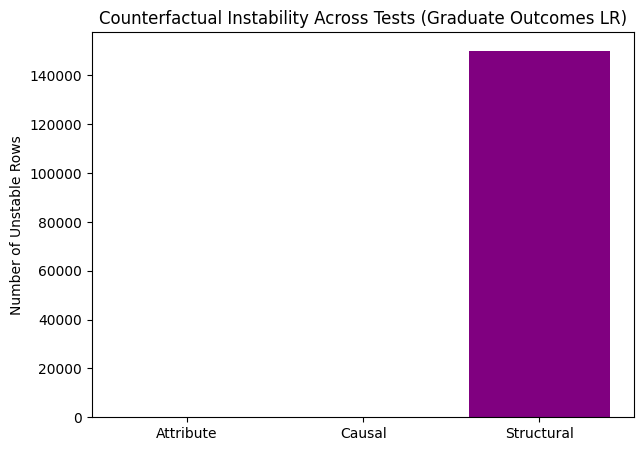

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(["Attribute", "Causal", "Structural"],
        [len(unstable_attr), len(unstable_causal), len(unstable_struct)],
        color=["blue", "green", "purple"])
plt.ylabel("Number of Unstable Rows")
plt.title("Counterfactual Instability Across Tests (Graduate Outcomes LR)")
plt.show()

As clearly seen, only structural instability was detected in this dataset, using the logistic regression model.

# 13. Export/ Save FairCleaned Dataset